Task:
    
Write a Python code to fit a straight line y = ax+b to an experimental dataset employing a Bayesian Markov Chain Monte Carlo (MCMC) sampler using the Metropolis-Hastings algorithm. 

The desired distribution is $\sim \mathcal{P}_{prior} \times e^{-1/2 \chi^2}$ where $$\chi^2 = \sum_i (\frac{y_{theo,i} - y_{exp,i}}{\sigma_i})^2.$$

Implementing both uniform and Gaussian form for prior distribution.

In `data` file, order is: x, f(x), error

In [1]:
import math
import random

In [2]:
# Split data into x, f(x), and error
# 1. Read the data
# 2. Split by lines
# 3. For each line split by whitespaces, create output lists
def read_file(path):

    # 1:
    with open(path, 'r') as file:
        data = file.read()

    x = []
    y = []
    e = []

    # 2:
    for line in data.splitlines():

        # 3:
        if not line.strip(): continue
        parts = line.split()
        x.append(float(parts[0]))
        y.append(float(parts[1]))
        e.append(float(parts[2]))

    return x, y, e

In [3]:
# Fit current data values to linear model
def fit_model(x, a, b):
    val = []

    for xi in x:
        val.append(a * xi + b)
        
    return val

# Calculate chi squared as given by the formula
# 1. Get theoretical values from the linear function
# 2. Loop through all data points and calculate chi squared
def get_chi2(x, y_exp, err, a, b):
    
    # 1:
    y_thr = fit_model(x, a, b)
    chi2 = 0.0

    # 2:
    for i in range(len(x)):
        chi2 += ((y_thr[i] - y_exp[i]) / err[i]) ** 2

    return chi2

In [4]:
# Calculate the prior probability for given a and b
# 1. Uniform distribution:
#   1.1. Unpack uniform distr. params: a_min, a_max, b_min, b_max - limits for linear function parameters
#   1.2. Check if a and b are within limits, return uniform probability or zero
# 2. Gaussian distribution:
#   2.1. Unpack Gaussian distr. params: a_mean, a_std, b_mean, b_std - mean and std for linear function parameters
#   2.2. Calculate the constant and exponent for the Gaussian formula
#   2.3. Calculate and return Gaussian probability
def get_prior(a, b, mode, params):

    # 1: Uniform distribution
    if mode == 'uniform':

        # 1.1:
        a_min, a_max, b_min, b_max = params

        # 1.2:
        if a_min <= a <= a_max and b_min <= b <= b_max:
            return 1.0 / ((a_max - a_min) * (b_max - b_min))
        else:
            return 0.0
    
    # 2: Gaussian distribution
    elif mode == 'gaussian':

        # 2.1:
        a_mean, a_std, b_mean, b_std = params

        # 2.2:
        constant = 1.0 / (2.0 * math.pi * a_std * b_std)
        exponent = -0.5 * (((a - a_mean) / a_std) ** 2 + ((b - b_mean) / b_std) ** 2)

        # 2.3:
        return constant * math.exp(exponent)
        
    return 0.0

# Calculate the posterior probability for given a and b
# 1. Get the prior probability of given mode
# 2. Get chi squared value and calculate the likelihood probability
# 3. Return the posterior as the product of prior and likelihood
def get_posterior(x, y_exp, err, a, b, mode, params):

    # 1:
    prior = get_prior(a, b, mode, params)
    if prior == 0.0:
        return 0.0
    
    # 2:
    chi2 = get_chi2(x, y_exp, err, a, b)
    prob = math.exp(-0.5 * chi2)

    # 3:
    return prior * prob

In [5]:
# Implements Metropolis - Hastings algorithm, runs simulation for N iterations, returns list of samples (a, b)
# 1. Read data from file and split it into x, f(x) and error
# 2. Initialize a and b
# 3. Calculate the initial posterior probability of given mode
# 4. For N iterations:
#   4.1. Select new a and b by adding a small random step with gaussian distribution
#   4.2. Calculate the new posterior probability of given mode
#   4.3. Calculate acceptance probability - ratio of new and old probabilities (may cause division by zero)
#   4.4. Accept or reject the new values based on acceptance probability
def metropolis_hastings(N, mode, params, step_size):
    
    # 1:
    x, y, err = read_file('data')

    # 2:
    a_old = 0.0
    b_old = 0.0

    # 3:
    post_old = get_posterior(x, y, err, a_old, b_old, mode, params)

    samples = []

    # 4 - for N iterations:
    for _ in range(N):

        # 4.1:
        a_new = a_old + random.gauss(0.0, step_size)
        b_new = b_old + random.gauss(0.0, step_size)

        # 4.2:
        post_new = get_posterior(x, y, err, a_new, b_new, mode, params)

        # 4.3:
        if post_old == 0.0:
            accept_prob = 1.0 if post_new > 0.0 else 0.0
        else:
            accept_prob = min(1.0, post_new / post_old)

        # 4.4:
        if random.random() < accept_prob:
            a_old = a_new
            b_old = b_new
            post_old = post_new

        samples.append((a_old, b_old))

    return samples

#### Run Simulation:

In [ ]:
N = 10_000
burn_in = int(0.25 * N)
step_size = 0.1

for mode in ['uniform', 'gaussian']:
    print(f"\nSimulation with {mode} distribution...")

    if mode == 'uniform':
        params = (-10.0, 10.0, -10.0, 10.0)
    else:
        params = (0.0, 10.0, 0.0, 10.0)

    samples = metropolis_hastings(N, mode, params, step_size)[burn_in:]

    a_samples = [s[0] for s in samples]
    b_samples = [s[1] for s in samples]

    a_final = sum(a_samples) / len(a_samples)
    b_final = sum(b_samples) / len(b_samples)

    a_variance = sum((a - a_final) ** 2 for a in a_samples) / len(a_samples)
    b_variance = sum((b - b_final) ** 2 for b in b_samples) / len(b_samples)
    a_std = math.sqrt(a_variance)
    b_std = math.sqrt(b_variance)

    print("\tResults")
    print(f"\tParameter a: {a_final:.4f} +/- {a_std:.4f}")
    print(f"\tParameter b: {b_final:.4f} +/- {b_std:.4f}")


Simulation with uniform distribution...
	Results
	Parametr a: 2.0420 +/- 0.0989
	Parametr b: -0.0081 +/- 0.0264

Simulation with gaussian distribution...
	Results
	Parametr a: 2.0387 +/- 0.0926
	Parametr b: -0.0072 +/- 0.0257


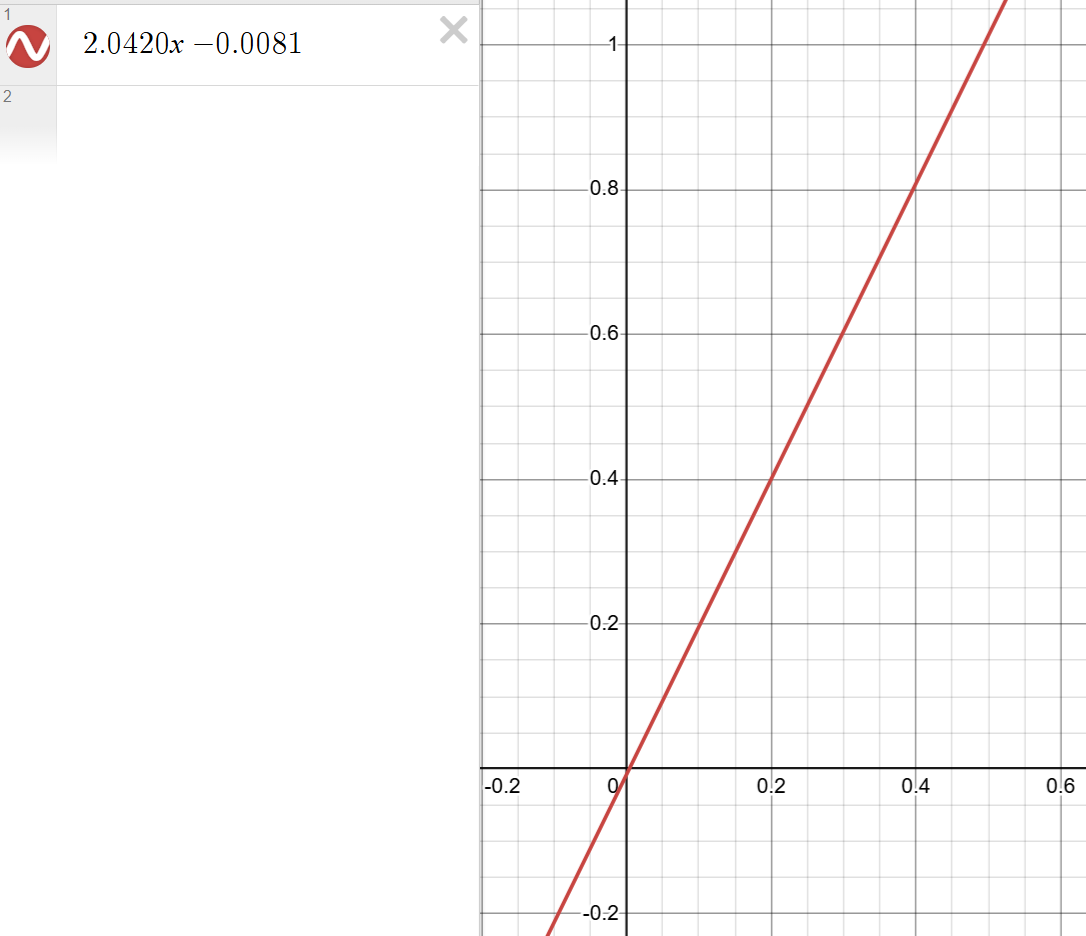
##### a and b when used to plot a linear function more or less match the list of known points from `data` file:
- 0.1 0.20 0.02
- 0.2 0.38 0.03
- 0.3 0.62 0.04
- 0.4 0.81 0.02